In [1]:
%config InlineBackend.figure_formats = {"retina", "png"}

import os
import tempfile

os.environ["OPENBLAS_NUM_THREADS"] = "1"

from IPython.display import HTML, display
import h5py
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (7.5, 2.5)

import tdgl
from tdgl.geometry import box, circle
from tdgl.visualization.animate import create_animation

In [2]:
length_units = "um"
xi = 0.1
london_lambda = 0.075
thickness = 0.05

height = 1
width = 2

layer = tdgl.Layer(coherence_length=xi, london_lambda=london_lambda, thickness=thickness)
film = tdgl.Polygon("film", points=tdgl.geometry.box(width, height, points=301))
device = tdgl.Device(
    "bar",
    layer=layer,
    film=film,
    length_units=length_units,
)

fluxoid_curves = [
    circle(0.25, center=(0, 0)),
    circle(0.1, center=(0.15, 0.25)),
    circle(0.3, center=(0.6, -0.1)),
    box(0.5, center=(-0.5, 0)),
    box(0.5, center=(-0.6, -0.2)),
]

In [3]:
device.make_mesh(max_edge_length=xi / 2, smooth=100)

Constructing Voronoi polygons: 100%|██████████| 2862/2862 [00:00<00:00, 27855.42it/s]


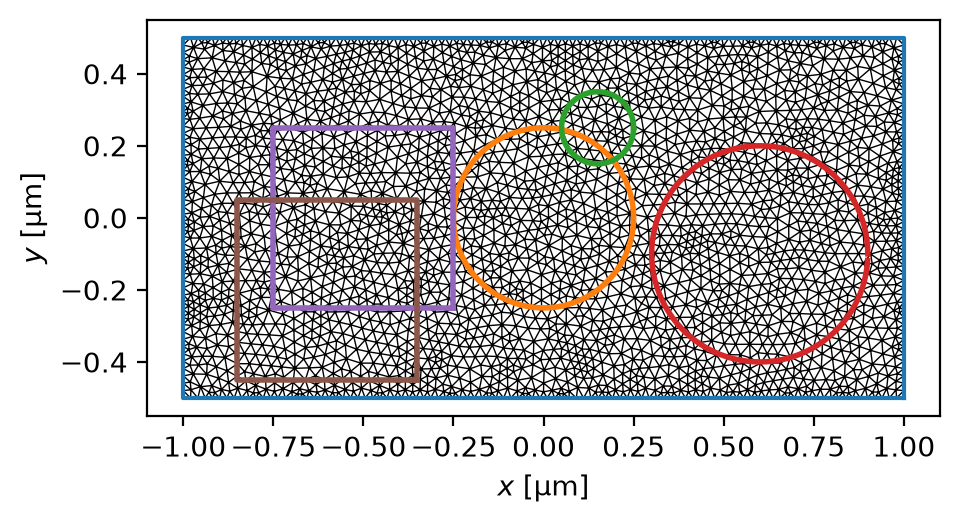

In [4]:
fig, ax = device.plot(mesh=True, legend=False)
for curve in fluxoid_curves:
    ax.plot(*curve.T, lw=2)

In [5]:
device.mesh_stats()

num_sites,2862
num_elements,5426
min_edge_length,1.285e-02
max_edge_length,4.828e-02
mean_edge_length,2.896e-02
min_area,9.328e-05
max_area,1.446e-03
mean_area,6.988e-04
coherence_length,1.000e-01
length_units,um


In [6]:
options = tdgl.SolverOptions(
    solve_time=5,
    field_units="mT",
    current_units="uA",
    include_screening=False,
)

no_screening_solution = tdgl.solve(device, options, applied_vector_potential=0.1)

Simulating: 100%|█████████▉| 5/5 [00:00<00:00, 12.36tau/s ]


Maximum sheet current density: 432.3 μA/μm
Curve 0: total fluxoid -1.260e-02 magnetic_flux_quantum, (error 392.6%)
Curve 1: total fluxoid -1.605e-03 magnetic_flux_quantum, (error 1307.6%)
Curve 2: total fluxoid -1.356e-02 magnetic_flux_quantum, (error 8527.5%)
Curve 3: total fluxoid -1.404e-02 magnetic_flux_quantum, (error 650.7%)
Curve 4: total fluxoid -1.007e-02 magnetic_flux_quantum, (error 613.0%)


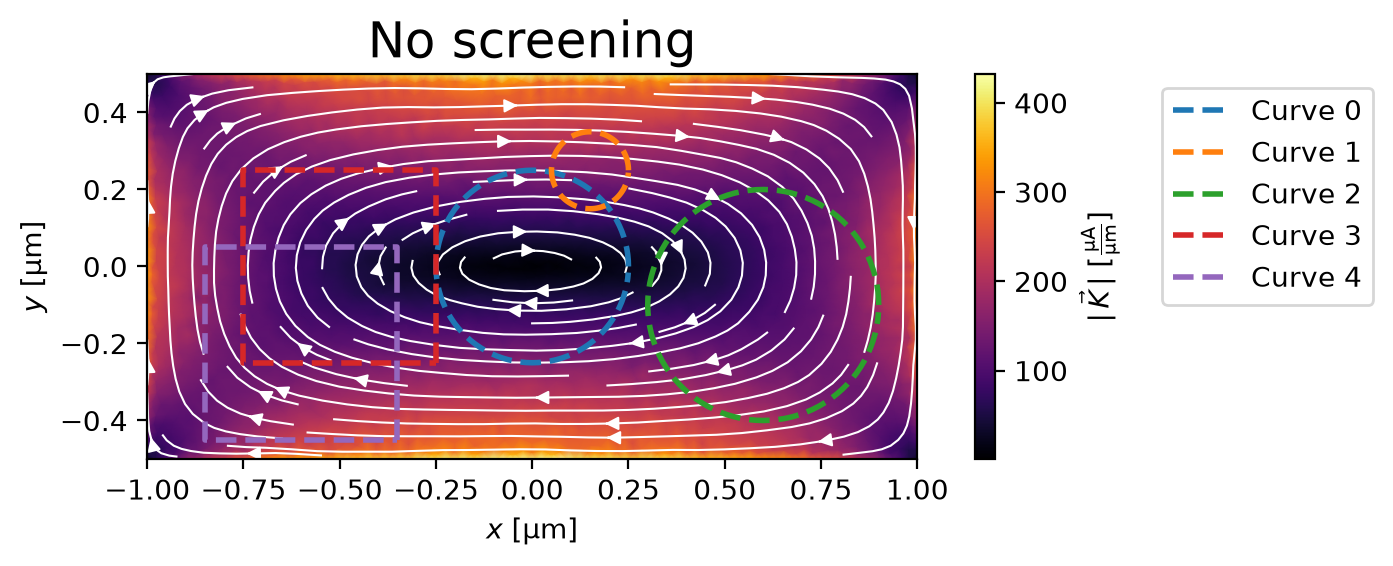

In [7]:
K = no_screening_solution.current_density
K_max = np.sqrt(K[:, 0]**2 + K[:, 1]**2).max()
print(f"Maximum sheet current density: {K_max:.1f~P}")

fig, ax = no_screening_solution.plot_currents()
_ = ax.set_title("No screening", fontsize=18)
for i, curve in enumerate(fluxoid_curves):
    fluxoid = no_screening_solution.polygon_fluxoid(curve)
    total_fluxoid = sum(fluxoid).magnitude
    error = abs(total_fluxoid / fluxoid.flux_part.magnitude)
    print(f"Curve {i}: total fluxoid {sum(fluxoid):.3e}, (error {100* error:.1f}%)")
    ax.plot(*curve.T, "--", lw=2, label=f"Curve {i}")

_ = ax.legend(bbox_to_anchor=(1.3, 1), loc="upper left")

In [8]:
options = tdgl.SolverOptions(
    solve_time=5,
    field_units="mT",
    current_units="uA",
    include_screening=True,
    screening_tolerance=1e-6,
    dt_max=1e-3,
)

screening_solution = tdgl.solve(device, options, applied_vector_potential=0.1)

Simulating: 100%|█████████▉| 5/5 [00:48<00:00,  9.79s/tau ]        


In [ ]:
K = screening_solution.current_density
K_max = np.sqrt(K[:, 0]**2 + K[:, 1]**2).max()
print(f"Maximum sheet current density: {K_max:.1f~P}")

fig, ax = screening_solution.plot_currents()
_ = ax.set_title("With screening", fontsize=18)

for i, curve in enumerate(fluxoid_curves):
    ax.plot(*curve.T, "--", lw=2, label=f"Curve {i}")
    fluxoid = screening_solution.polygon_fluxoid(curve)
    total_fluxoid = sum(fluxoid).magnitude
    error = abs(total_fluxoid / fluxoid.flux_part.magnitude)
    print(f"Curve {i}: total fluxoid {sum(fluxoid):.3e}, (error {100 * error:.1f}%)")

_ = ax.legend(bbox_to_anchor=(1.3, 1), loc="upper left")

In [ ]:
tdgl.version_table()